In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['font.sans-serif'] = 'Roboto'   # Specific font name
plt.rcParams['font.size'] = 12              # Default text size in points
plt.rcParams['font.style'] = 'normal'       # Options: normal, italic, oblique
plt.rcParams['font.weight'] = 'normal'      # Options: normal, bold, etc.
plt.rcParams["lines.linewidth"] = 3.0  # Set global default line width

In [ ]:
colors = [
    "#1F71C9",  # Blue
    "#F58518",  # Orange
    "#54A24B",  # Green
    "#E45756",  # Red
    "#72B7B2",  # Teal
    "#B279A2",  # Purple
    "#FF9DA6",  # Pink
    "#9D755D",  # Brown
    "#BAB0AC",  # Gray
    "#2F4B7C"   # Dark blue
]

In [3]:
df = pd.read_csv("../datasets/sales_data_cln.csv").copy()

In [4]:
df.columns

Index(['user_id', 'order_id', 'purchase_ts', 'ship_ts', 'refund_ts',
       'product_name', 'product_id', 'usd_price', 'purchase_platform',
       'marketing_channel', 'account_creation_method', 'country_code',
       'purchase_y', 'purchase_ym', 'purchase_ymd', 'purchase_ymw',
       'purchase_q', 'ship_y', 'ship_ym', 'ship_ymd', 'ship_ymw', 'ship_q'],
      dtype='str')

In [5]:
df.head()

,user_id,order_id,purchase_ts,ship_ts,refund_ts,product_name,product_id,usd_price,purchase_platform,marketing_channel,...,purchase_y,purchase_ym,purchase_ymd,purchase_ymw,purchase_q,ship_y,ship_ym,ship_ymd,ship_ymw,ship_q
0,2c06175e,0001328c3c220830,2020-12-24 00:00:00,2020-12-13,NaN,Nintendo Switch,e682,168.00,website,affiliate,...,2020,2020-12,2020-12-24,2020-12-21/2020-12-27,2020Q4,2020,2020-12,2020-12-13,2020-12-07/2020-12-13,2020Q4
1,ee8e5bc2,0002af7a5c6100772,2020-10-01 00:00:00,2020-09-21,NaN,Nintendo Switch,e682,160.61,website,direct,...,2020,2020-10,2020-10-01,2020-09-28/2020-10-04,2020Q4,2020,2020-09,2020-09-21,2020-09-21/2020-09-27,2020Q3
2,9eb4efe0,0002b8350e167074,2020-04-21 00:00:00,2020-02-16,NaN,Nintendo Switch,8d0d,151.20,website,direct,...,2020,2020-04,2020-04-21,2020-04-20/2020-04-26,2020Q2,2020,2020-02,2020-02-16,2020-02-10/2020-02-16,2020Q1
3,cac7cbaf,0006d06b98385729,2020-04-07 00:00:00,2020-04-04,4/28/2022,Sony PlayStation 5 Bundle,54ed,1132.82,website,direct,...,2020,2020-04,2020-04-07,2020-04-06/2020-04-12,2020Q2,2020,2020-04,2020-04-04,2020-03-30/2020-04-05,2020Q2
4,6b0230bc,00097279a2f46150,2020-11-24 00:00:00,2020-08-02,NaN,Nintendo Switch,8d0d,33.89,website,direct,...,2020,2020-11,2020-11-24,2020-11-23/2020-11-29,2020Q4,2020,2020-08,2020-08-02,2020-07-27/2020-08-02,2020Q3


In [6]:
ref = df[~df["refund_ts"].isna()]

In [7]:
ref.head(3)

,user_id,order_id,purchase_ts,ship_ts,refund_ts,product_name,product_id,usd_price,purchase_platform,marketing_channel,...,purchase_y,purchase_ym,purchase_ymd,purchase_ymw,purchase_q,ship_y,ship_ym,ship_ymd,ship_ymw,ship_q
3,cac7cbaf,0006d06b98385729,2020-04-07 00:00:00,2020-04-04,4/28/2022,Sony PlayStation 5 Bundle,54ed,1132.82,website,direct,...,2020,2020-04,2020-04-07,2020-04-06/2020-04-12,2020Q2,2020,2020-04,2020-04-04,2020-03-30/2020-04-05,2020Q2
14,68673786,003ed9bd3d71799,2020-10-26 00:00:00,2020-06-01,6/28/2025,Nintendo Switch,8d0d,134.41,website,direct,...,2020,2020-10,2020-10-26,2020-10-26/2020-11-01,2020Q4,2020,2020-06,2020-06-01,2020-06-01/2020-06-07,2020Q2
22,0d688544,006b12955f18514,2020-04-01 00:00:00,2019-11-29,4/16/2022,27in 4K gaming monitor,891b,480.00,website,direct,...,2020,2020-04,2020-04-01,2020-03-30/2020-04-05,2020Q2,2019,2019-11,2019-11-29,2019-11-25/2019-12-01,2019Q4


In [8]:
prod_lost_ym = ref.groupby(["purchase_ym", "product_name"]).agg(total_lost=("usd_price", "sum"), total_orders = ("order_id", "count")).reset_index()
prod_lost_ym.head(10)

,purchase_ym,product_name,total_lost,total_orders
0,2019-01,27in 4K gaming monitor,3931.83,9
1,2019-01,JBL Quantum 100 Gaming Headset,139.93,6
2,2019-01,Lenovo IdeaPad Gaming 3,1992.03,3
3,2019-01,Nintendo Switch,2625.10,16
4,2019-02,27in 4K gaming monitor,2608.01,6
5,2019-02,Acer Nitro V Gaming Laptop,719.82,1
6,2019-02,JBL Quantum 100 Gaming Headset,86.87,4
7,2019-02,Lenovo IdeaPad Gaming 3,1198.00,1
8,2019-02,Nintendo Switch,1535.78,9
9,2019-02,Sony PlayStation 5 Bundle,1800.00,1


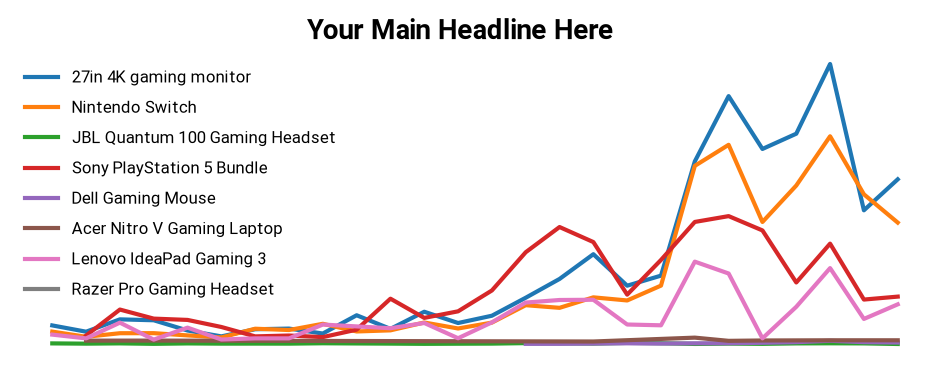

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

# ax.bar(rev_data_ym["order_year_month"], rev_data_ym["total_net_revenue"], label='Product A', color='#4dabf7')

prod_01 = prod_lost_ym[(prod_lost_ym["product_name"] == "27in 4K gaming monitor")]
prod_02 = prod_lost_ym[prod_lost_ym["product_name"] == "Nintendo Switch"]
prod_03 = prod_lost_ym[prod_lost_ym["product_name"] == "JBL Quantum 100 Gaming Headset"]
prod_04 = prod_lost_ym[prod_lost_ym["product_name"] == "Sony PlayStation 5 Bundle"]
prod_05 = prod_lost_ym[prod_lost_ym["product_name"] == "Dell Gaming Mouse"]
prod_06 = prod_lost_ym[prod_lost_ym["product_name"] == "Acer Nitro V Gaming Laptop"]
prod_07 = prod_lost_ym[prod_lost_ym["product_name"] == "Lenovo IdeaPad Gaming 3"]
prod_08 = prod_lost_ym[prod_lost_ym["product_name"] == "Razer Pro Gaming Headset"]


ax.plot(prod_01["purchase_ym"], prod_01["total_lost"], label = "27in 4K gaming monitor")
ax.plot(prod_02["purchase_ym"], prod_02["total_lost"], label = "Nintendo Switch")
ax.plot(prod_03["purchase_ym"], prod_03["total_lost"], label = "JBL Quantum 100 Gaming Headset")
ax.plot(prod_04["purchase_ym"], prod_04["total_lost"], label = "Sony PlayStation 5 Bundle")
ax.plot(prod_05["purchase_ym"], prod_05["total_lost"], label = "Dell Gaming Mouse")
ax.plot(prod_06["purchase_ym"], prod_06["total_lost"], label = "Acer Nitro V Gaming Laptop")
ax.plot(prod_07["purchase_ym"], prod_07["total_lost"], label = "Lenovo IdeaPad Gaming 3")
ax.plot(prod_08["purchase_ym"], prod_08["total_lost"], label = "Razer Pro Gaming Headset")

# ax.scatter(rev_data_ym["order_year_month"], rev_data_ym["gross_margin"])

plt.suptitle('Your Main Headline Here', fontsize=20, fontweight='bold')
ax.legend(frameon = False)



ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])
plt.savefig("../figures/refunds/product_performance_ref.png", transparent=True, dpi=300)
# ax.set_title("GROSS MARGIN PER MONTH")

plt.show()

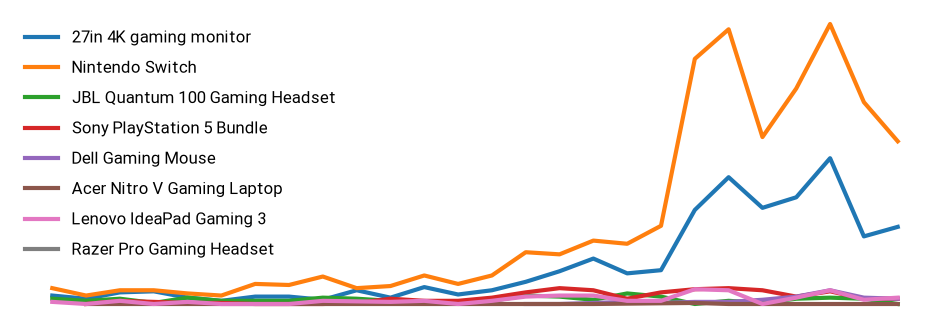

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))

prod_01 = prod_lost_ym[(prod_lost_ym["product_name"] == "27in 4K gaming monitor")]
prod_02 = prod_lost_ym[prod_lost_ym["product_name"] == "Nintendo Switch"]
prod_03 = prod_lost_ym[prod_lost_ym["product_name"] == "JBL Quantum 100 Gaming Headset"]
prod_04 = prod_lost_ym[prod_lost_ym["product_name"] == "Sony PlayStation 5 Bundle"]
prod_05 = prod_lost_ym[prod_lost_ym["product_name"] == "Dell Gaming Mouse"]
prod_06 = prod_lost_ym[prod_lost_ym["product_name"] == "Acer Nitro V Gaming Laptop"]
prod_07 = prod_lost_ym[prod_lost_ym["product_name"] == "Lenovo IdeaPad Gaming 3"]
prod_08 = prod_lost_ym[prod_lost_ym["product_name"] == "Razer Pro Gaming Headset"]


ax.plot(prod_01["purchase_ym"], prod_01["total_orders"], label = "27in 4K gaming monitor")
ax.plot(prod_02["purchase_ym"], prod_02["total_orders"], label = "Nintendo Switch")
ax.plot(prod_03["purchase_ym"], prod_03["total_orders"], label = "JBL Quantum 100 Gaming Headset")
ax.plot(prod_04["purchase_ym"], prod_04["total_orders"], label = "Sony PlayStation 5 Bundle")
ax.plot(prod_05["purchase_ym"], prod_05["total_orders"], label = "Dell Gaming Mouse")
ax.plot(prod_06["purchase_ym"], prod_06["total_orders"], label = "Acer Nitro V Gaming Laptop")
ax.plot(prod_07["purchase_ym"], prod_07["total_orders"], label = "Lenovo IdeaPad Gaming 3")
ax.plot(prod_08["purchase_ym"], prod_08["total_orders"], label = "Razer Pro Gaming Headset")

ax.legend(frameon = False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])
plt.savefig("../figures/refunds/product_performance_ref_orders.png", transparent=True, dpi=300)
# ax.set_title("GROSS MARGIN PER MONTH")

plt.show()

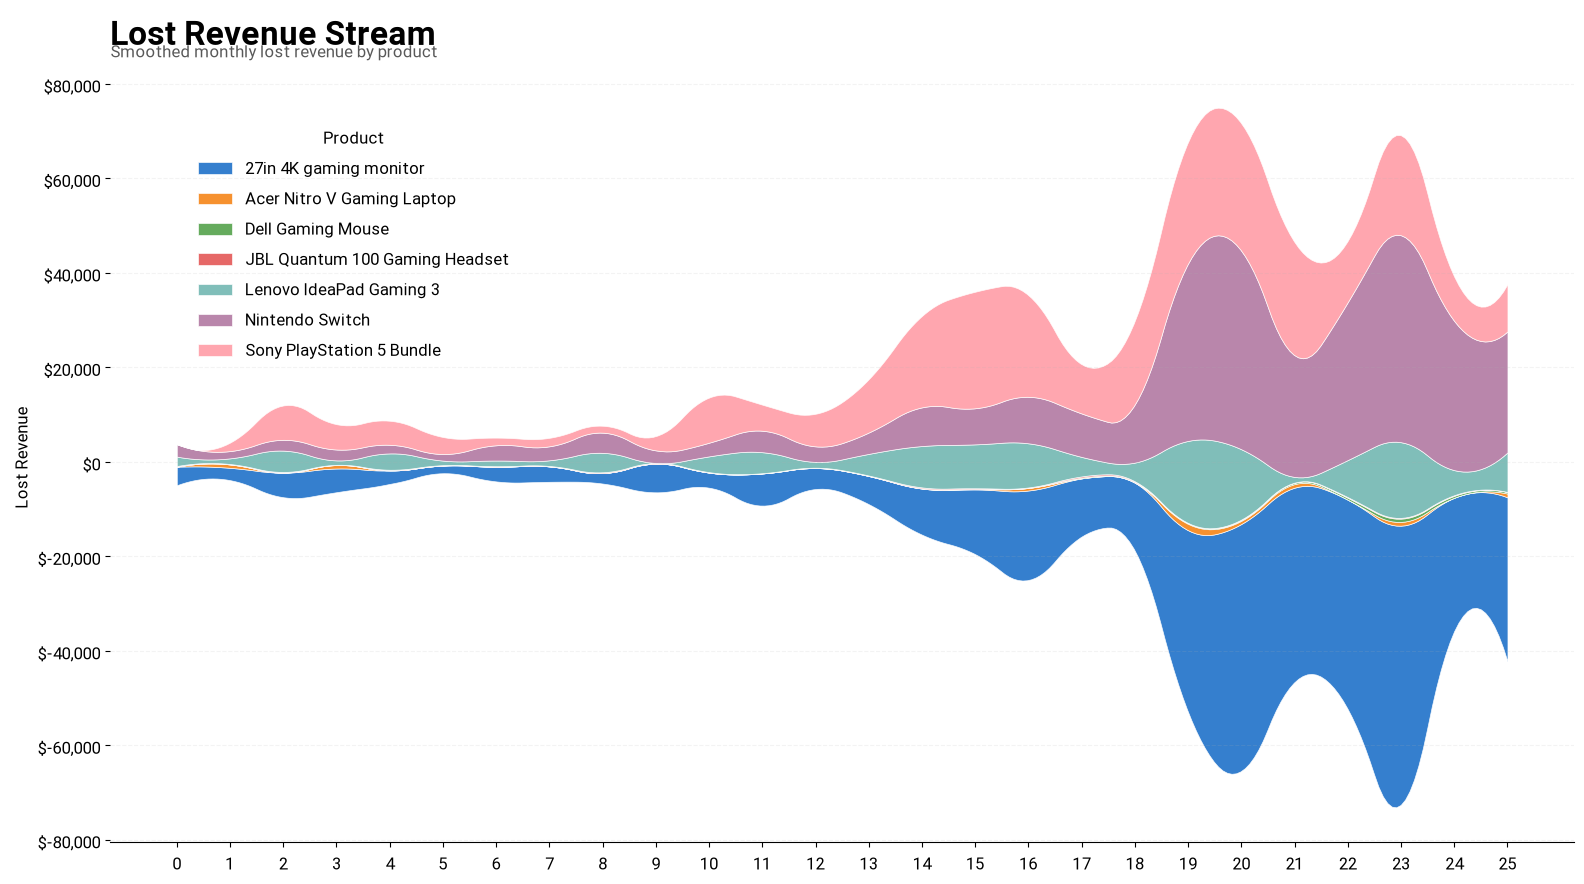

In [16]:
from scipy.interpolate import make_interp_spline
from matplotlib.ticker import FuncFormatter

colors = [
    "#1F71C9",  # Blue
    "#F58518",  # Orange
    "#54A24B",  # Green
    "#E45756",  # Red
    "#72B7B2",  # Teal
    "#B279A2",  # Purple
    "#FF9DA6",  # Pink
    "#9D755D",  # Brown
    "#BAB0AC",  # Gray
    "#2F4B7C"   # Dark blue
]

# ---------------------------------------
# Pivot
# ---------------------------------------

pivot = (
    prod_lost_ym.pivot_table(
        index="purchase_ym",
        columns="product_name",
        values="total_lost",
        aggfunc="sum",
        fill_value=0
    )
    .sort_index()
)

# ---------------------------------------
# Convert dates to numeric positions
# ---------------------------------------

x = np.arange(len(pivot))

# Create many intermediate points
x_smooth = np.linspace(
    x.min(),
    x.max(),
    300
)

# ---------------------------------------
# Smooth each product
# ---------------------------------------

smooth_data = []

for product in pivot.columns:

    y = pivot[product].values

    # Cubic spline
    spline = make_interp_spline(
        x,
        y,
        k=2  # quadratic; use k=3 with >= 4 observations
    )

    y_smooth = spline(x_smooth)

    # Prevent negative revenue caused by interpolation
    y_smooth = np.maximum(y_smooth, 0)

    smooth_data.append(y_smooth)

smooth_data = np.array(smooth_data)

# ---------------------------------------
# Plot
# ---------------------------------------

fig, ax = plt.subplots(figsize=(16, 9))

ax.stackplot(
    x_smooth,
    smooth_data,
    labels=pivot.columns,
    colors=colors[:len(pivot.columns)],
    baseline="wiggle",
    alpha=0.90,
    edgecolor="white",
    linewidth=0.5
)
# ---------------------------------------
# X-axis
# ---------------------------------------

ax.set_xticks(x)

"""ax.set_xticklabels(
    pivot.index.strftime("%b %Y")
)"""

# ---------------------------------------
# Formatting
# ---------------------------------------

ax.set_title(
    "Lost Revenue Stream",
    fontsize=24,
    fontweight="bold",
    loc="left",
    pad=20
)

ax.text(
    0,
    1.02,
    "Smoothed monthly lost revenue by product",
    transform=ax.transAxes,
    fontsize=12,
    alpha=0.65
)

ax.set_ylabel("Lost Revenue")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.grid(
    axis="y",
    alpha=0.15,
    linestyle="--"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(
    title="Product",
    loc="upper left",
    bbox_to_anchor=(0.05, 0.95),
    frameon=False
)

plt.savefig("../figures/refunds/lost_revenue_strea,.png", transparent=True, dpi=300)

plt.tight_layout()
plt.show()

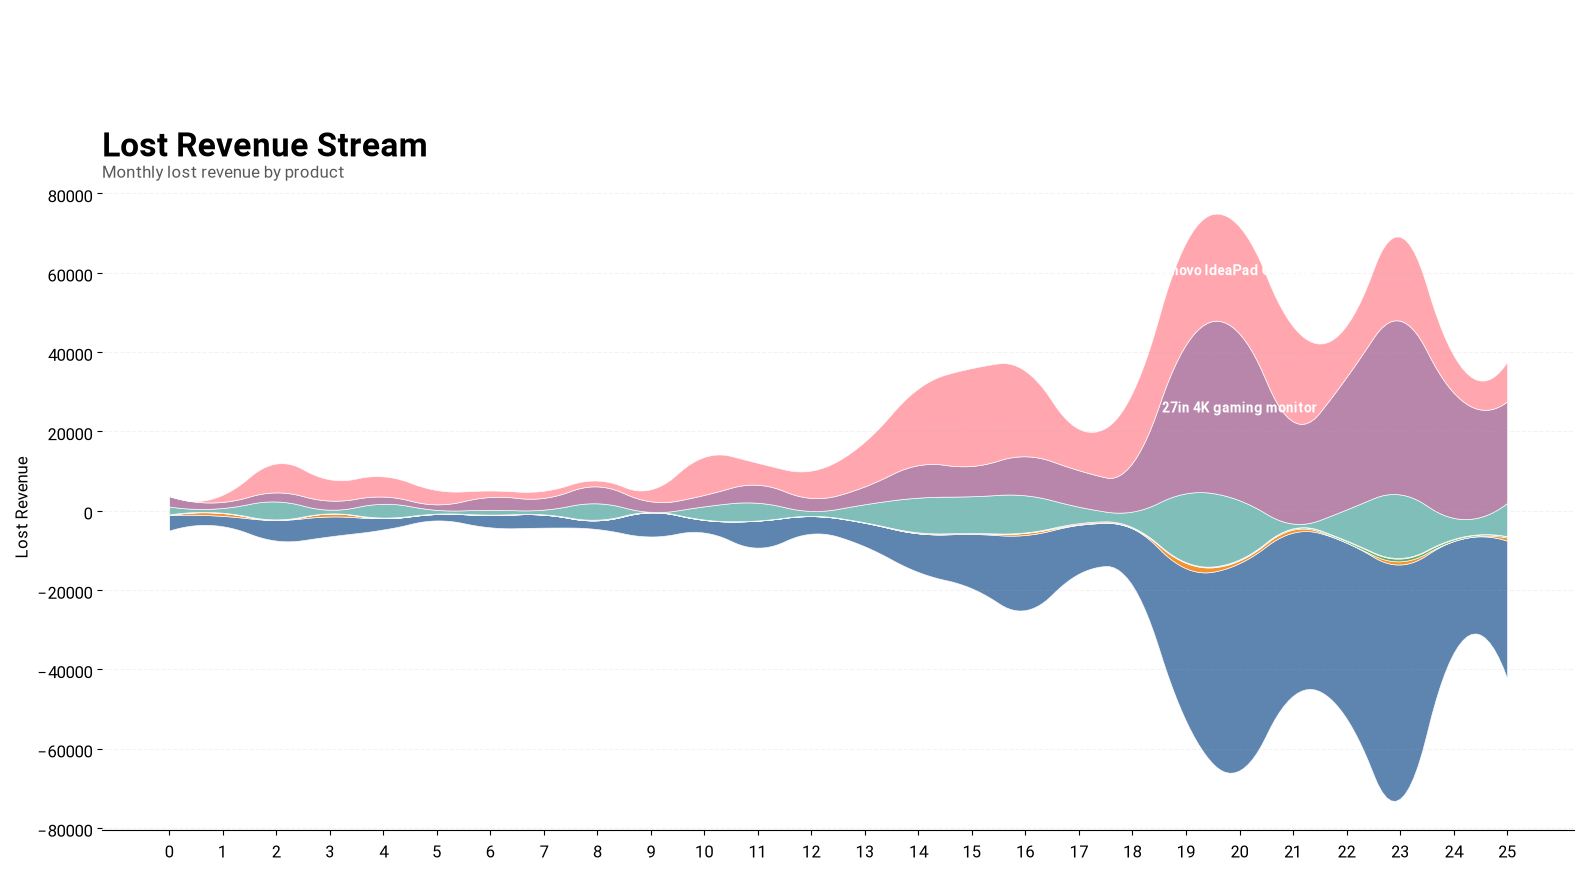

In [ ]:
fig, ax = plt.subplots(figsize=(16, 9))

colors = [
    "#4C78A8",
    "#F58518",
    "#54A24B",
    "#E45756",
    "#72B7B2",
    "#B279A2",
    "#FF9DA6",
    "#9D755D",
    "#2F4B7C",
    "#59A14F"
]

# -----------------------------------------
# Streamgraph
# -----------------------------------------

ax.stackplot(
    x_smooth,
    smooth_data,
    labels=pivot.columns,
    colors=colors[:len(pivot.columns)],
    baseline="wiggle",
    alpha=0.90,
    edgecolor="white",
    linewidth=0.5
)

# -----------------------------------------
# Choose annotation position
# -----------------------------------------

# Usually 70–85% across the chart works well
annotation_x = 0.80

x_position = (
    x_smooth.min()
    + annotation_x *
    (x_smooth.max() - x_smooth.min())
)

x_index = np.argmin(
    np.abs(x_smooth - x_position)
)

# -----------------------------------------
# Calculate vertical center of each stream
# -----------------------------------------

# For a stacked streamgraph, calculate the
# bottom and top of each stream at the
# chosen x position.

values_at_x = smooth_data[:, x_index]

cumulative = np.cumsum(values_at_x)

bottom = np.concatenate(
    [[0], cumulative[:-1]]
)

top = cumulative

centers = (
    bottom + top
) / 2

# -----------------------------------------
# Annotate streams
# -----------------------------------------

for i, product in enumerate(pivot.columns):

    stream_height = values_at_x[i]

    # Ignore very small streams
    if stream_height < values_at_x.max() * 0.08:
        continue

    ax.text(
        x_position,
        centers[i],
        product,
        fontsize=10,
        fontweight="bold",
        ha="center",
        va="center",
        color="white"
    )

# -----------------------------------------
# Title
# -----------------------------------------

ax.set_title(
    "Lost Revenue Stream",
    fontsize=24,
    fontweight="bold",
    loc="left",
    pad=20
)

ax.text(
    0,
    1.01,
    "Monthly lost revenue by product",
    transform=ax.transAxes,
    fontsize=12,
    alpha=0.65
)

# -----------------------------------------
# X-axis
# -----------------------------------------

ax.set_xticks(x)
"""
ax.set_xticklabels(
    pivot.index.strftime("%b %Y")
)"""

ax.set_ylabel("Lost Revenue")

# -----------------------------------------
# Clean design
# -----------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.15,
    linestyle="--"
)

plt.tight_layout()
plt.show()

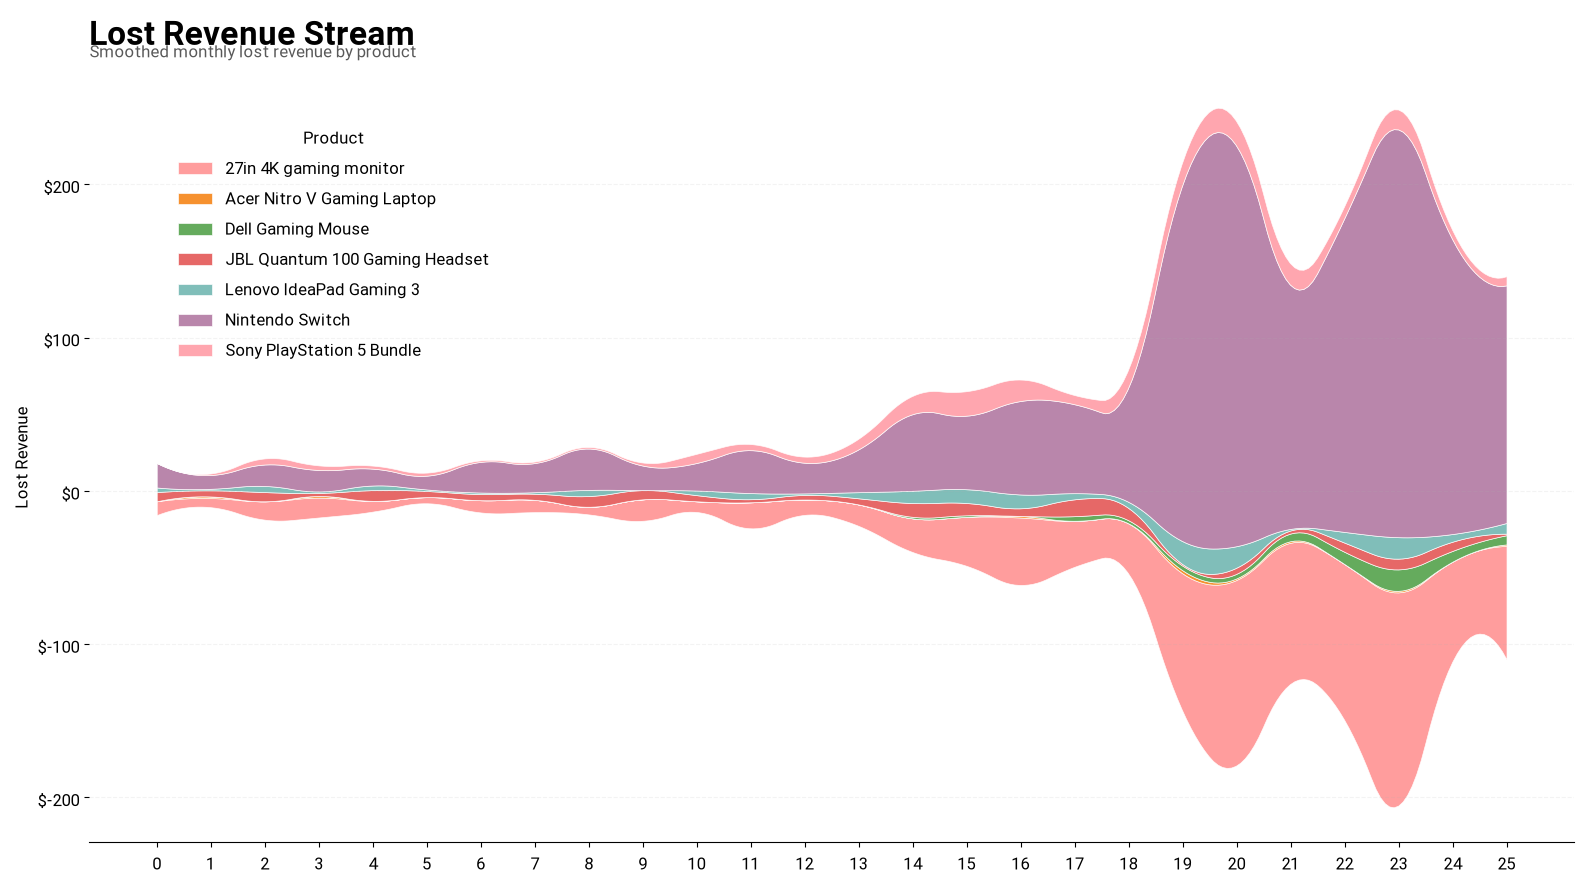

In [ ]:
from scipy.interpolate import make_interp_spline
from matplotlib.ticker import FuncFormatter

# ---------------------------------------
# Pivot
# ---------------------------------------

pivot = (
    prod_lost_ym.pivot_table(
        index="purchase_ym",
        columns="product_name",
        values="total_orders",
        aggfunc="sum",
        fill_value=0
    )
    .sort_index()
)

# ---------------------------------------
# Convert dates to numeric positions
# ---------------------------------------

x = np.arange(len(pivot))

# Create many intermediate points
x_smooth = np.linspace(
    x.min(),
    x.max(),
    300
)

# ---------------------------------------
# Smooth each product
# ---------------------------------------

smooth_data = []

for product in pivot.columns:

    y = pivot[product].values

    # Cubic spline
    spline = make_interp_spline(
        x,
        y,
        k=2  # quadratic; use k=3 with >= 4 observations
    )

    y_smooth = spline(x_smooth)

    # Prevent negative revenue caused by interpolation
    y_smooth = np.maximum(y_smooth, 0)

    smooth_data.append(y_smooth)

smooth_data = np.array(smooth_data)

# ---------------------------------------
# Plot
# ---------------------------------------

fig, ax = plt.subplots(figsize=(16, 9))

ax.stackplot(
    x_smooth,
    smooth_data,
    labels=pivot.columns,
    colors=colors[:len(pivot.columns)],
    baseline="wiggle",
    alpha=0.90,
    edgecolor="white",
    linewidth=0.5
)
# ---------------------------------------
# X-axis
# ---------------------------------------

ax.set_xticks(x)

"""ax.set_xticklabels(
    pivot.index.strftime("%b %Y")
)"""

# ---------------------------------------
# Formatting
# ---------------------------------------

ax.set_title(
    "Lost Revenue Stream",
    fontsize=24,
    fontweight="bold",
    loc="left",
    pad=20
)

ax.text(
    0,
    1.02,
    "Smoothed monthly lost revenue by product",
    transform=ax.transAxes,
    fontsize=12,
    alpha=0.65
)

ax.set_ylabel("Lost Revenue")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.grid(
    axis="y",
    alpha=0.15,
    linestyle="--"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(
    title="Product",
    loc="upper left",
    bbox_to_anchor=(0.05, 0.95),
    frameon=False
)

plt.savefig("../figures/refunds/lost_revenue_orders.png", transparent=True, dpi=300)

plt.tight_layout()
plt.show()